In [1]:
import tf_silent
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
from pinn import PINN
from network import Network
from optimizer import L_BFGS_B

In [2]:
def mass_cons(network, xy):
    """
    Compute u_x and v_y
    Args:
        xy: network input variables as ndarray.
    Returns:
        (u_x, v_y) as ndarray.
    """

    xy = tf.constant(xy)
    x, y = [ xy[..., i, tf.newaxis] for i in range(xy.shape[-1]) ]
    with tf.GradientTape(persistent=True) as g:
      g.watch(x)
      g.watch(y)

      u_v_p = network(tf.concat([x, y], axis=-1))
      u = u_v_p[..., 0, tf.newaxis]
      v = u_v_p[..., 1, tf.newaxis]
      p = u_v_p[..., 2, tf.newaxis]
    u_x = g.batch_jacobian(u, x)[..., 0]
    v_y = g.batch_jacobian(v, y)[..., 0]

    return u_x.numpy(), v_y.numpy()


In [3]:
def u_0(xy):
    """
    Initial wave form.
    Args:
        tx: variables (t, x) as tf.Tensor.
    Returns:
        u(t, x) as tf.Tensor.
    """

    x = xy[..., 0, None]
    y = xy[..., 1, None]


    return    4*y*(1 - y) 


In [4]:
def contour(x, y, z, title, levels=100):
    """
    Contour plot.
    Args:
        grid: plot position.
        x: x-array.
        y: y-array.
        z: z-array.
        title: title string.
        levels: number of contour lines.
    """

    # get the value range
    vmin = np.min(z)
    vmax = np.max(z)
    # plot a contour
    font1 = {'family':'serif','size':20}
    plt.contour(x, y, z, colors='k', linewidths=0.2, levels=levels)
    plt.contourf(x, y, z, cmap='rainbow', levels=levels, norm=Normalize(vmin=vmin, vmax=vmax))
    plt.axes()
    circle = plt.Circle((0.5,0.5),0.1, fc='black')
    plt.gca().add_patch(circle)
    plt.axis('scaled')
    plt.title(title, fontdict = font1)
    plt.xlabel("x", fontdict = font1)
    plt.ylabel("y", fontdict = font1)
    plt.tick_params(axis='both', which='major', labelsize=15)

    cbar = plt.colorbar(pad=0.03, aspect=25, format='%.0e')
    cbar.mappable.set_clim(vmin, vmax)
    cbar.ax.tick_params(labelsize=15)



In [7]:
import os
import numpy as np
import json
from matplotlib.patches import Circle

import matplotlib.pyplot as plt

# Reynolds numbers to try
reynolds_list = [10, 20, 40, 100, 500, 1000]
results = []
rho = 1.0  # density
num_train_samples = 4000  # number of training samples

# Domain and circle data
x_f = 2
x_ini = 0
y_f = 1
y_ini = 0
Cx = 0.5
Cy = 0.5
a = 0.1
b = 0.1

xyt_circle = np.random.rand(num_train_samples, 2)
xyt_circle[..., 0] = 2 * (a) * xyt_circle[..., 0] + (Cx - a)
xyt_circle[0:num_train_samples // 2, 1] = b * (1 - (xyt_circle[0:num_train_samples // 2, 0] - Cx) ** 2 / a ** 2) ** 0.5 + Cy
xyt_circle[num_train_samples // 2:, 1] = -b * (1 - (xyt_circle[num_train_samples // 2:, 0] - Cx) ** 2 / a ** 2) ** 0.5 + Cy

# create training input
xyt_eqn = np.random.rand(num_train_samples, 2)
xyt_eqn[..., 0] = (x_f - x_ini) * xyt_eqn[..., 0] + x_ini
xyt_eqn[..., 1] = (y_f - y_ini) * xyt_eqn[..., 1] + y_ini

for i in range(num_train_samples):
  while (xyt_eqn[i, 0] - Cx) ** 2 / a ** 2 + (xyt_eqn[i, 1] - Cy) ** 2 / b ** 2 < 1:
    xyt_eqn[i, 0] = (x_f - x_ini) * np.random.rand(1, 1) + x_ini
    xyt_eqn[i, 1] = (y_f - y_ini) * np.random.rand(1, 1) + y_ini

xyt_w1 = np.random.rand(num_train_samples, 2)
xyt_w1[..., 0] = (x_f - x_ini) * xyt_w1[..., 0] + x_ini
xyt_w1[..., 1] = y_ini

xyt_w2 = np.random.rand(num_train_samples, 2)
xyt_w2[..., 0] = (x_f - x_ini) * xyt_w2[..., 0] + x_ini
xyt_w2[..., 1] = y_f

xyt_out = np.random.rand(num_train_samples, 2)
xyt_out[..., 0] = x_f

xyt_in = np.random.rand(num_train_samples, 2)
xyt_in[..., 0] = x_ini

x_train = [xyt_eqn, xyt_w1, xyt_w2, xyt_out, xyt_in, xyt_circle]

# create training output
zeros = np.zeros((num_train_samples, 3))
a_in = u_0(tf.constant(xyt_in)).numpy()
b_in = np.zeros((num_train_samples, 1))
onze = np.random.permutation(np.concatenate([a_in, b_in, a_in], axis=-1))

y_train = [zeros, onze, zeros, zeros, zeros, zeros]
model_dir = "model_data"
os.makedirs(model_dir, exist_ok=True)

for Re in reynolds_list:
  mu = 1.0 / Re  # update viscosity for each Re
  model_name = f"Re_{Re}"
  run_dir = model_dir
  plot_dir = model_dir

  # build a core network model
  network = Network().build()
  network.summary()
  # build a PINN model
  pinn = PINN(network, rho=rho, mu=mu).build()

  # train the model using L-BFGS-B algorithm
  lbfgs = L_BFGS_B(model=pinn, x_train=x_train, y_train=y_train)
  lbfgs.fit()
  final_loss = lbfgs.loss_history[-1] if lbfgs.loss_history else None
  
  # Save model
  model_path = os.path.join(run_dir, f'{model_name}.keras')
  network.save(model_path)

  font1 = {'family': 'serif', 'size': 20}

  # Inference mesh
  x = np.linspace(x_ini, x_f, 300)
  y = np.linspace(y_ini, y_f, 300)
  x_grid, y_grid = np.meshgrid(x, y)
  xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)

  # Predict (u, v, p)
  u_v_p = network.predict(xy_flat, batch_size=len(xy_flat))
  u = u_v_p[..., 0].reshape(x_grid.shape)
  v = u_v_p[..., 1].reshape(x_grid.shape)
  p = u_v_p[..., 2].reshape(x_grid.shape)

  # Wake region (define x_start, x_end, y_start, y_end as needed)
  x_start, x_end = 0.6, 1.2
  y_start, y_end = 0.35, 0.65
  mask = (x_grid >= x_start) & (x_grid <= x_end) & (y_grid >= y_start) & (y_grid <= y_end)
  u_wake = u[mask]
  min_u_wake = np.min(u_wake)
  print(f"Model {model_name}: Minimum u velocity in wake region = {min_u_wake:.4f}")

  # Save u contour plot
  fig0, ax0 = plt.subplots(1, 1, figsize=(20, 8))
  cf0 = ax0.contourf(x_grid, y_grid, u, np.arange(-0.5, 1.1, .02), extend='both', cmap='rainbow')
  cbar0 = plt.colorbar(cf0)
  ax0.add_patch(Circle((0.5, 0.5), 0.1, color="black"))
  plt.title(f"{model_name}: u", fontdict=font1)
  plt.xlabel("x", fontdict=font1)
  plt.ylabel("y", fontdict=font1)
  plt.tick_params(axis='both', which='major', labelsize=15)
  cbar0.ax.tick_params(labelsize=15)
  plt.tight_layout()
  u_plot_path = os.path.join(plot_dir, f"{model_name}_u.png")
  plt.savefig(u_plot_path, dpi=300)
  plt.close()

  # Save streamlines plot
  fig1, ax1 = plt.subplots(1, 1, figsize=(20, 8))
  ax1.streamplot(x_grid, y_grid, u, v, color='k', density=5, linewidth=0.25)
  ax1.add_patch(Circle((0.5, 0.5), 0.1, color="black"))
  plt.title(f"{model_name}: Streamlines", fontdict=font1)
  plt.xlabel("x", fontdict=font1)
  plt.ylabel("y", fontdict=font1)
  plt.tick_params(axis='both', which='major', labelsize=15)
  plt.tight_layout()
  stream_plot_path = os.path.join(plot_dir, f"{model_name}_streamlines.png")
  plt.savefig(stream_plot_path, dpi=300)
  plt.close()

  # Save a summary for this run
  summary_path = os.path.join(run_dir, f'{model_name}_training_summary.json')
  summary = {
    'final_loss': float(final_loss) if final_loss is not None else None,
    'min_u_wake': float(min_u_wake),
    'model_filename': str(model_path),
    'u_plot': str(u_plot_path),
    'streamline_plot': str(stream_plot_path)
  }
  with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

  results.append(summary)

# Save full summary for all runs
with open(os.path.join(model_dir, 'all_training_summary_2.json'), 'w') as f:
  json.dump(results, f, indent=2)

# Print best run
best_run = min(results, key=lambda x: x['final_loss'])
print("\n Best Manual Weight Run:")
print(f"final_loss: {best_run['final_loss']}")
print(f"min_u_wake: {best_run['min_u_wake']:.4f}")
print(f"model file: {best_run['model_filename']}")

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_10 (Dense)            (None, 48)                144       
                                                                 
 dense_11 (Dense)            (None, 48)                2352      
                                                                 
 dense_12 (Dense)            (None, 48)                2352      
                                                                 
 dense_13 (Dense)            (None, 48)                2352      
                                                                 
 dense_14 (Dense)            (None, 3)                 147       
                                                                 
Total params: 7347 (28.70 KB)
Trainable params: 7347 (28.70

/tmp/ipykernel_3572918/4284174981.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xyt_eqn[i, 0] = (x_f - x_ini) * np.random.rand(1, 1) + x_ini
/tmp/ipykernel_3572918/4284174981.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  xyt_eqn[i, 1] = (y_f - y_ini) * np.random.rand(1, 1) + y_ini


Optimizer: L-BFGS-B (maxiter=30000)
1/1 [==============================] - 0s 121ms/step
Model Re_10: Minimum u velocity in wake region = 0.0045
Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_15 (Dense)            (None, 48)                144       
                                                                 
 dense_16 (Dense)            (None, 48)                2352      
                                                                 
 dense_17 (Dense)            (None, 48)                2352      
                                                                 
 dense_18 (Dense)            (None, 48)                2352      
                                                                 
 dense_19 (Dense)            (None, 3)        

In [9]:
def plot_profiles(x, y, u, v, cross_sections):
    """
    Plot velocity profiles (u, v) along specified cross-sections.
    Args:
        x: x-array (meshgrid).
        y: y-array (meshgrid).
        u: u-array (velocity in x-direction).
        v: v-array (velocity in y-direction).
        cross_sections: List of cross-sections to plot. Each cross-section is a tuple (type, value).
                        'type' can be 'x' or 'y', and 'value' is the coordinate value.
                        Example: [('x', 0), ('y', 0), ('y', 1), ('x', 0.75)]
    """
    for section in cross_sections:
        section_type, value = section
        if section_type == 'x':  # Vertical line (constant x)
            idx = np.argmin(np.abs(x[0, :] - value))  # Find the closest x index
            plt.figure(figsize=(8, 6))
            plt.plot(y[:, idx], u[:, idx], label='u (x={})'.format(value))
            plt.plot(y[:, idx], v[:, idx], label='v (x={})'.format(value))
            plt.xlabel('y')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at x = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()
        elif section_type == 'y':  # Horizontal line (constant y)
            idx = np.argmin(np.abs(y[:, 0] - value))  # Find the closest y index
            plt.figure(figsize=(8, 6))
            plt.plot(x[idx, :], u[idx, :], label='u (y={})'.format(value))
            plt.plot(x[idx, :], v[idx, :], label='v (y={})'.format(value))
            plt.xlabel('x')
            plt.ylabel('Velocity')
            plt.title('Velocity Profiles at y = {}'.format(value))
            plt.legend()
            plt.grid()
            plt.show()

In [8]:
!pwd

/mnt/data_dzne_archiv2/Studien/Deep_Learning_Visualization/temporary_stuff/Jaya_Chandra_Terli/SS-2025/SLB-Project/reproduce/Navier_Stokes_cylinder2D/reproduce/trainings/reynls_study


1/1 [==============================] - 0s 103ms/step
Re=10: MAE = 0.1537, RMSE = 0.1802


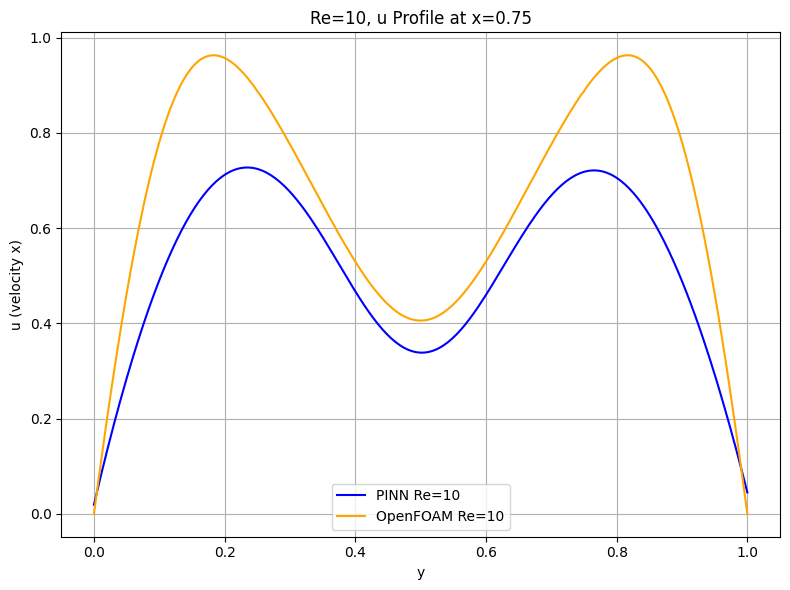

1/1 [==============================] - 0s 128ms/step
Re=100: MAE = 0.0933, RMSE = 0.1052


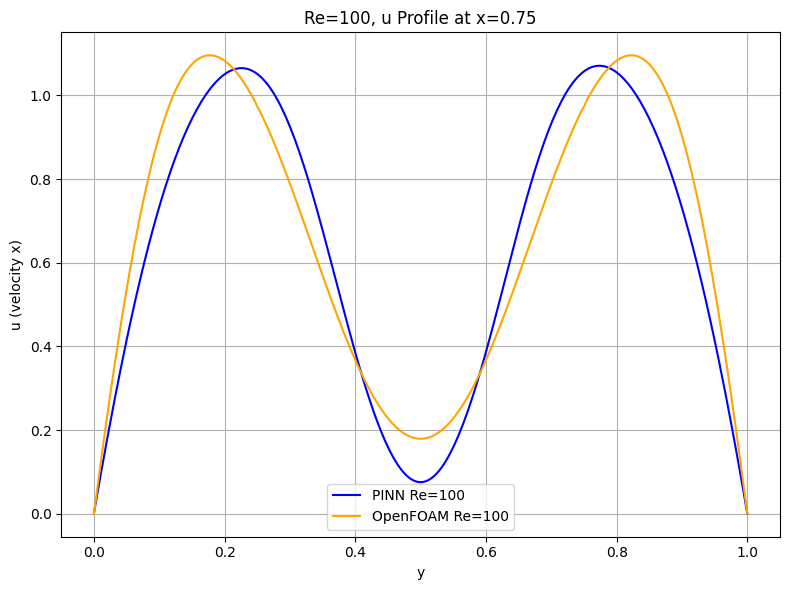

1/1 [==============================] - 0s 95ms/step
Re=1000: MAE = 0.1136, RMSE = 0.1367


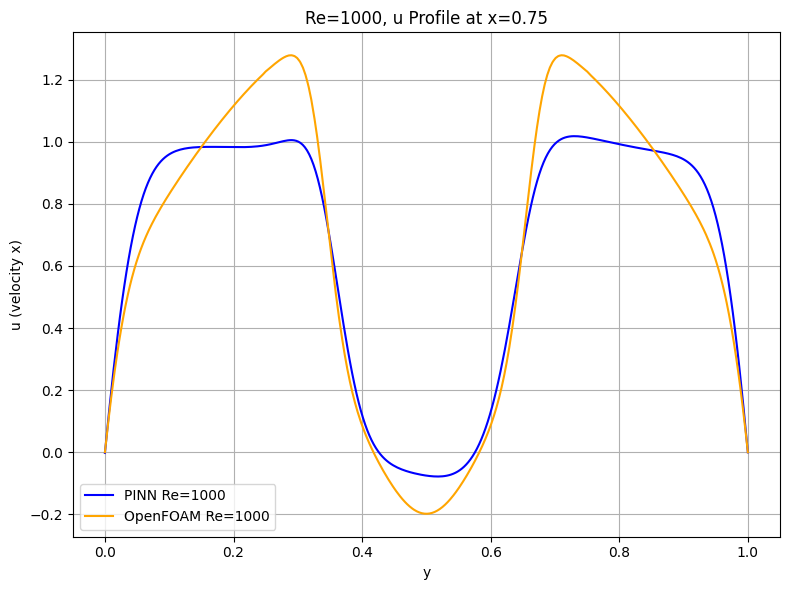

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
from scipy.interpolate import interp1d
import os

def plot_profile_comparison(y_pinn, u_pinn, y_ref, u_ref, label_pinn="PINN", label_ref="OpenFOAM", 
                           title="Velocity Profile Comparison", save_path=None):
    """
    Plot and compare two velocity profiles along the same cross-section.
    Args:
        y_pinn: y-coordinates for PINN data.
        u_pinn: velocity values for PINN data.
        y_ref: y-coordinates for reference data (e.g., OpenFOAM).
        u_ref: velocity values for reference data.
        label_pinn: label for PINN data.
        label_ref: label for reference data.
        title: plot title.
        save_path: path to save the plot (optional).
    """
    plt.figure(figsize=(8, 6))
    plt.plot(y_pinn, u_pinn, label=label_pinn, color='blue')
    plt.plot(y_ref, u_ref, label=label_ref, color='orange')
    plt.xlabel('y')
    plt.ylabel('u (velocity x)')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300)
    
    plt.show()


# --- File paths ---
reynolds = [10, 100, 1000]
openfoam_csvs = [
    "../../data/Re10_Med_Ux/Re10_Med_Ux_0.75.csv",
    "../../data/Re100_Med_Ux/Re100_Med_Ux_0.75.csv",
    "../../data/Re1000_Med_Ux/Re1000_Med_Ux_0.75.csv"
]
model_paths = [
    "model_data/Re_10.keras",
    "model_data/Re_100.keras",
    "model_data/Re_1000.keras"
]

# Create output directory for plots
plots_dir = "model_data/profile_comparisons"
os.makedirs(plots_dir, exist_ok=True)

# --- For each Re, plot PINN vs OpenFOAM at x=0.75 ---
for re, csv_path, model_path in zip(reynolds, openfoam_csvs, model_paths):
    # Load OpenFOAM data
    df = pd.read_csv(csv_path)
    y_ref = df["arc_length"] if "arc_length" in df.columns else df.iloc[:,0]
    u_ref = df["U_X"] if "U_X" in df.columns else df.iloc[:,1]

    # Load PINN model
    model = keras.models.load_model(model_path, compile=False)

    # Create inference mesh (should match your training/inference mesh)
    x = np.linspace(0, 2, 300)
    y = np.linspace(0, 1, 300)
    x_grid, y_grid = np.meshgrid(x, y)

    # Find index closest to x=0.75
    x_target = 0.75
    idx = np.argmin(np.abs(x - x_target))
    y_pinn = y  # y-grid at x=0.75

    # Predict on the whole mesh, then extract u at x=0.75
    xy_flat = np.stack([x_grid.flatten(), y_grid.flatten()], axis=-1)
    u_v_p = model.predict(xy_flat, batch_size=len(xy_flat))
    u = u_v_p[:, 0].reshape(x_grid.shape)
    u_pinn = u[:, idx]

    # Interpolate PINN profile onto OpenFOAM's y-coordinates
    u_pinn_interp = interp1d(y_pinn, u_pinn, kind='linear', bounds_error=False, fill_value='extrapolate')
    u_pinn_on_ref = u_pinn_interp(y_ref)

    # Compute errors
    mae = np.mean(np.abs(u_pinn_on_ref - u_ref))
    rmse = np.sqrt(np.mean((u_pinn_on_ref - u_ref)**2))

    print(f"Re={re}: MAE = {mae:.4f}, RMSE = {rmse:.4f}")
    # Save path for this comparison
    save_path = os.path.join(plots_dir, f"profile_comparison_Re{re}.png")

    # Plot comparison
    plot_profile_comparison(
        y_pinn, u_pinn, y_ref, u_ref,
        label_pinn=f"PINN Re={re}",
        label_ref=f"OpenFOAM Re={re}",
        title=f"Re={re}, u Profile at x=0.75",
        save_path=save_path
    )

In [37]:
import numpy as np
from scipy.interpolate import interp1d

# y_pinn, u_pinn: PINN y and u values at x=0.75
# y_ref, u_ref: OpenFOAM y and u values at x=0.75

# Interpolate PINN profile onto OpenFOAM's y-coordinates
u_pinn_interp = interp1d(y_pinn, u_pinn, kind='linear', bounds_error=False, fill_value='extrapolate')
u_pinn_on_ref = u_pinn_interp(y_ref)

# Compute errors
mae = np.mean(np.abs(u_pinn_on_ref - u_ref))
rmse = np.sqrt(np.mean((u_pinn_on_ref - u_ref)**2))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.0741
RMSE: 0.0903
